# Define constants

In [22]:
import librosa
import os
from os import path

SOURCE_PATH = path.normpath("../../../validations/")

# Least audio duration
AUDIO_SAMPLE_RATE = 48_000 # Hz

# How many frames to skip in each samples
CQT_HOP_LENGTH = 512

# Bin numbers based on octaves for input
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36

# Starts from note
CQT_FMIN = librosa.note_to_hz('C1')

# Set to false to use spectral flux
USE_SUPERFLUX = False

# Paper targets fr=200fps with mu=2.
# Derive mu by matching the intended time gap: mu * hop / sr ≈ 2 * (1/200)
TARGET_LAG_SECONDS = 2 * (1 / 200)  # 10ms — paper's effective look-back window
lag = max(1, round(TARGET_LAG_SECONDS * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH))

# max_size: fixed by paper's m-1:m+1 neighborhood definition, always 3
max_size = 3

# Superflux parameters (Boeck and Widmer 2013)
SUPERFLUX_PARAMETERS = {
  "sr": AUDIO_SAMPLE_RATE,
  "hop_length": CQT_HOP_LENGTH,
  "lag": lag,
  "max_size": max_size,
}

# Onset detection parameters
PEAK_PICKING_MCFEE = {
  "delta": 0.07,
  "pre_max": 30,
  "post_max": 1, # 0, must be positive in librosa
  "pre_avg": 100,
  "post_avg": 100,
  "wait": 30,
}

PEAK_PICKING_BOCK = {
  # "delta": default,
  "pre_max": 30,
  "post_max": 30,
  "pre_avg": 100,
  "post_avg": 70,
  "wait": 30,
}

PEAK_PICKING_BOCK_ONLINE = {
  # "delta": default,
  "pre_max": 30,
  "post_max": 1, # 0, must be positive in librosa
  "pre_avg": 100,
  "post_avg": 1, # 0, must be positive in librosa
  "wait": 30,
}

print(SUPERFLUX_PARAMETERS)

{'sr': 48000, 'hop_length': 512, 'lag': 1, 'max_size': 3}


# Show annotation plots

In [23]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np


def plot_feature_true_and_detected_onsets(
    sample_cqt,
    true_annotations,
    detected_onset_times=None,
    *,
    dataset_name="",
    sample_label=None,
    ax=None,
    title=None,
):
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

    image = librosa.display.specshow(
        sample_cqt,
        x_axis='time',
        y_axis='cqt_note',
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        fmin=CQT_FMIN,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
        ax=ax,
    )

    y_bottom = ax.get_ylim()[0]
    for annotation in true_annotations:
        onset_time = annotation["start"]
        chord_name = annotation["chord"]
        ax.axvline(onset_time, color="cyan", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(
            onset_time,
            y_bottom,
            chord_name,
            va="bottom",
            ha="left",
            fontsize=8,
            color="cyan",
            bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=1),
        )

    if detected_onset_times is not None:
        for onset_time in np.atleast_1d(detected_onset_times):
            ax.axvline(onset_time, color="magenta", linestyle="-", linewidth=1, alpha=0.8)

    ax.text(
        0.01,
        0.98,
        dataset_name,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        color="cyan",
        bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=2),
    )

    if title is None:
        title_parts = []
        if dataset_name:
            title_parts.append(dataset_name)
        if sample_label is not None:
            title_parts.append(f"sample label: {sample_label}")
        title_parts.append(f"frames: {sample_cqt.shape[1]}")
        title = " | ".join(title_parts)

    ax.set_title(title)
    return image, ax

# Onset detection

## Define functions

In [24]:
def target_npz_path(dataset_name):
    return path.join(SOURCE_PATH, f"{dataset_name}.npz")

def cqt_to_db(sample_cqt):
    if np.min(sample_cqt) < 0:
        return sample_cqt

    # Guards against log of zero by changing zero values in the CQT with the smallest positive number
    safe_cqt = np.maximum(sample_cqt, np.finfo(np.float32).tiny)
    return librosa.power_to_db(safe_cqt, ref=np.max)

def detect_onsets_from_cqt(sample_cqt, parameters):
    cqt_db = cqt_to_db(sample_cqt) if USE_SUPERFLUX else sample_cqt
    onset_envelope = librosa.onset.onset_strength(
        S=cqt_db,
        **SUPERFLUX_PARAMETERS if USE_SUPERFLUX else {},
    )

    onset_frames = librosa.onset.onset_detect(
        onset_envelope=onset_envelope,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        **parameters,
    )

    onset_times = librosa.frames_to_time(
        onset_frames,
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
    )

    return onset_frames, onset_times, onset_envelope

def detect_onsets_for_dataset(dataset_name, parameters):
    npz_path = target_npz_path(dataset_name)
    data = np.load(npz_path, allow_pickle=True)
    features = data["features"]
    labels = data["labels"]
    annotations = data["annotations"]

    detections = []
    for sample_index, sample_cqt in enumerate(features):
        onset_frames, onset_times, onset_envelope = detect_onsets_from_cqt(sample_cqt, parameters)
        detections.append({
            "sample_index": sample_index,
            "label": labels[sample_index],
            "annotation": annotations[sample_index],
            "onset_frames": onset_frames,
            "onset_times": onset_times,
            "onset_envelope": onset_envelope,
        })

    return {
        "dataset_name": dataset_name,
        "features": features,
        "labels": labels,
        "annotations": annotations,
        "detections": detections,
    }

def detect_onsets_for_all_datasets(dataset_names, parameters):
  detections = {
      dataset_name: detect_onsets_for_dataset(dataset_name, parameters) for dataset_name in dataset_names
  }

  fig, axes = plt.subplots(len(validation_datasets), 1, figsize=(14, 18), constrained_layout=True)

  for axis, dataset_name in zip(axes, validation_datasets):
      dataset_result = detections[dataset_name]
      sample_cqt = dataset_result["features"][0]
      annotations = dataset_result["annotations"][0]
      detected_onset_times = dataset_result["detections"][0]["onset_times"]

      image, _ = plot_feature_true_and_detected_onsets(
          sample_cqt,
          annotations,
          detected_onset_times=detected_onset_times,
          dataset_name=dataset_name,
          sample_label=dataset_result["labels"][0],
          ax=axis,
      )
      fig.colorbar(image, ax=axis)

  plt.show()

  return detections

validation_datasets = [d for d in os.listdir(SOURCE_PATH) if os.path.isdir(os.path.join(SOURCE_PATH, d))]

## McFee et al

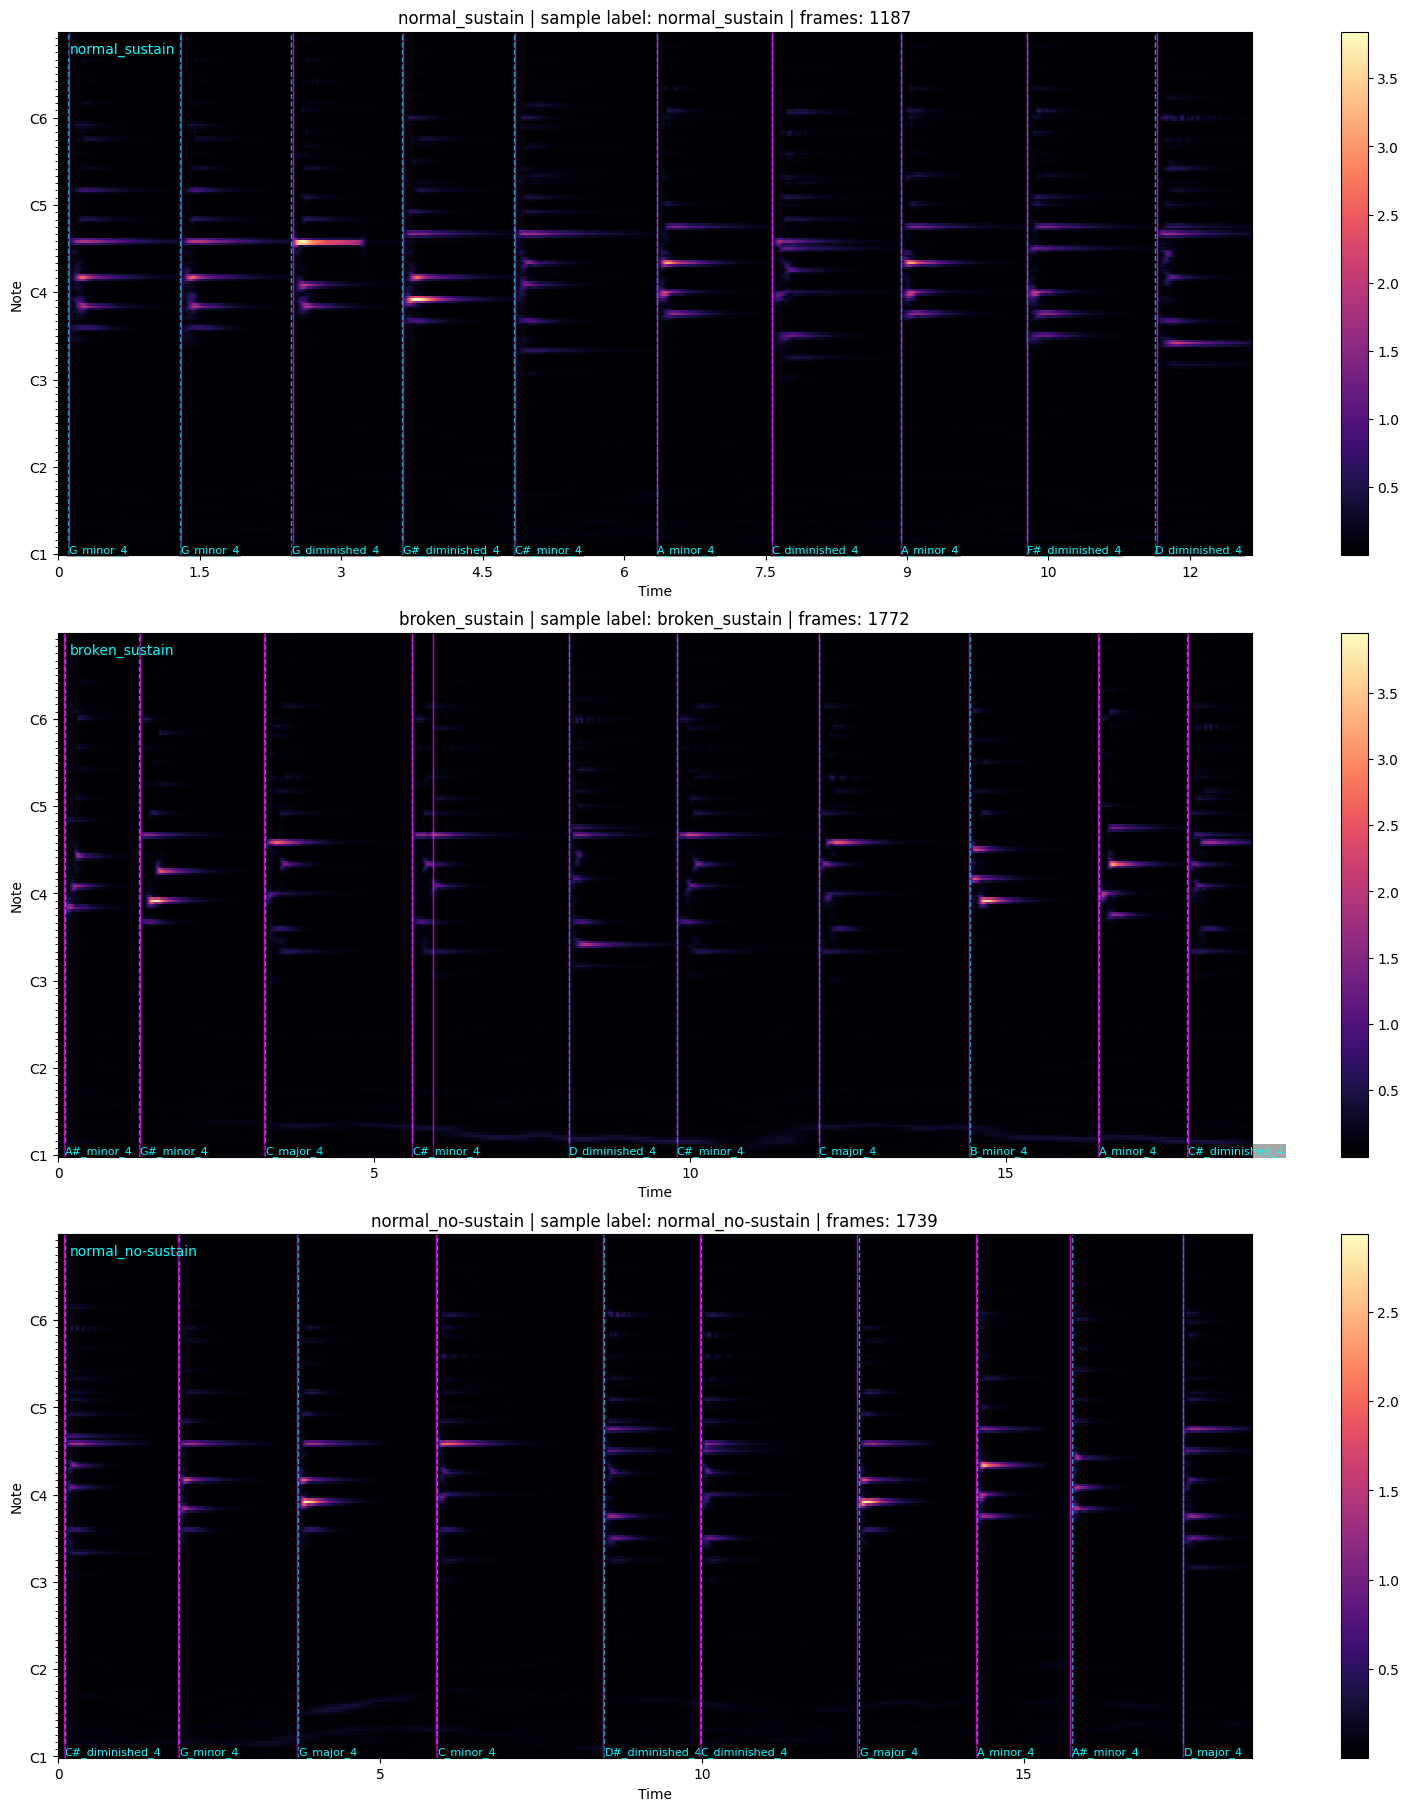

In [25]:
mcfee_detections = detect_onsets_for_all_datasets(validation_datasets, PEAK_PICKING_MCFEE)

## Bock & Widmer Offline

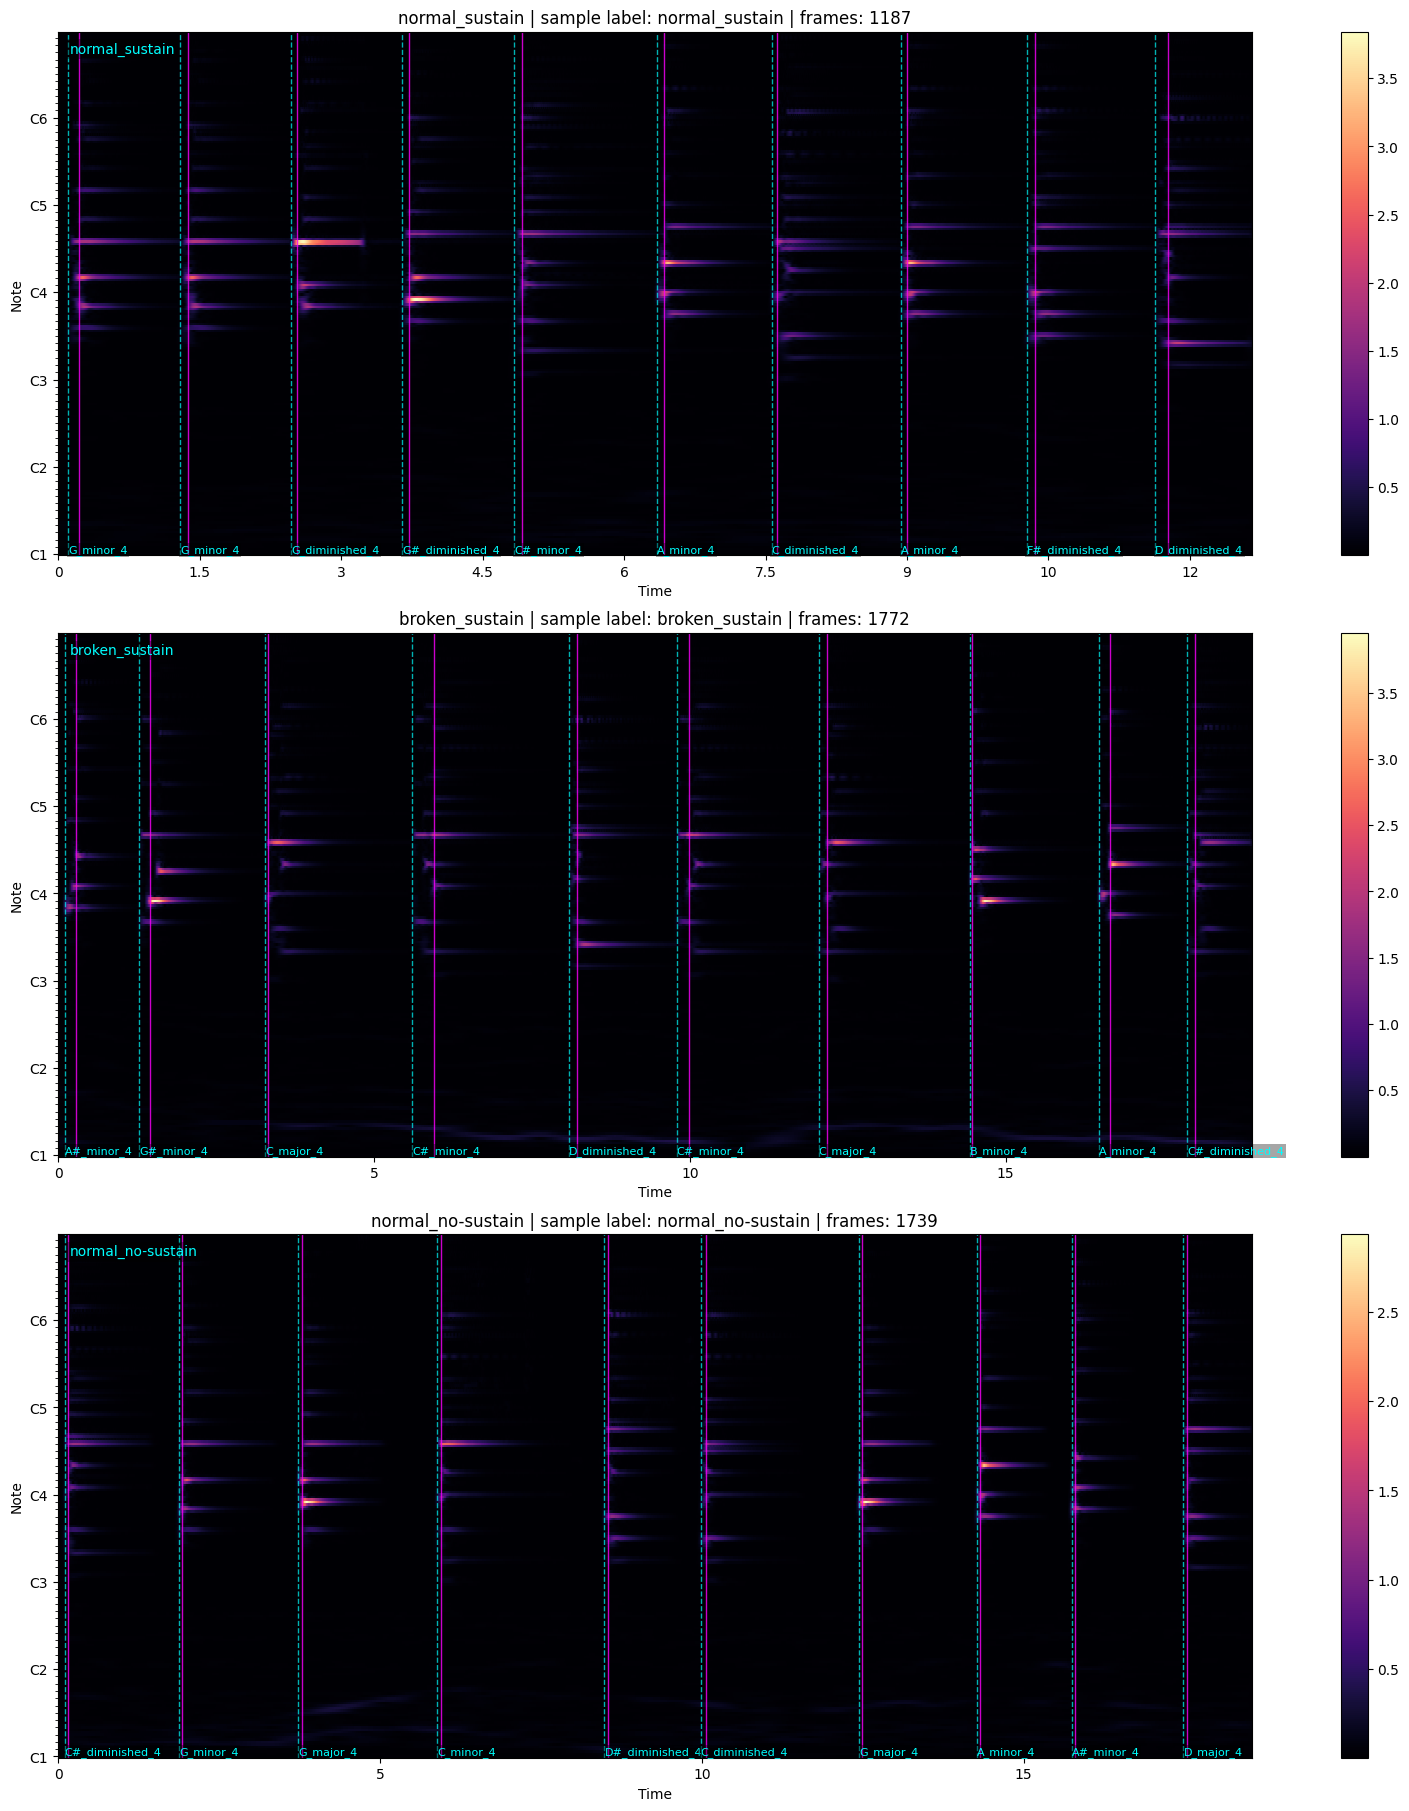

In [26]:
bock_detections = detect_onsets_for_all_datasets(validation_datasets, PEAK_PICKING_BOCK)

## Bock & Widmer Online

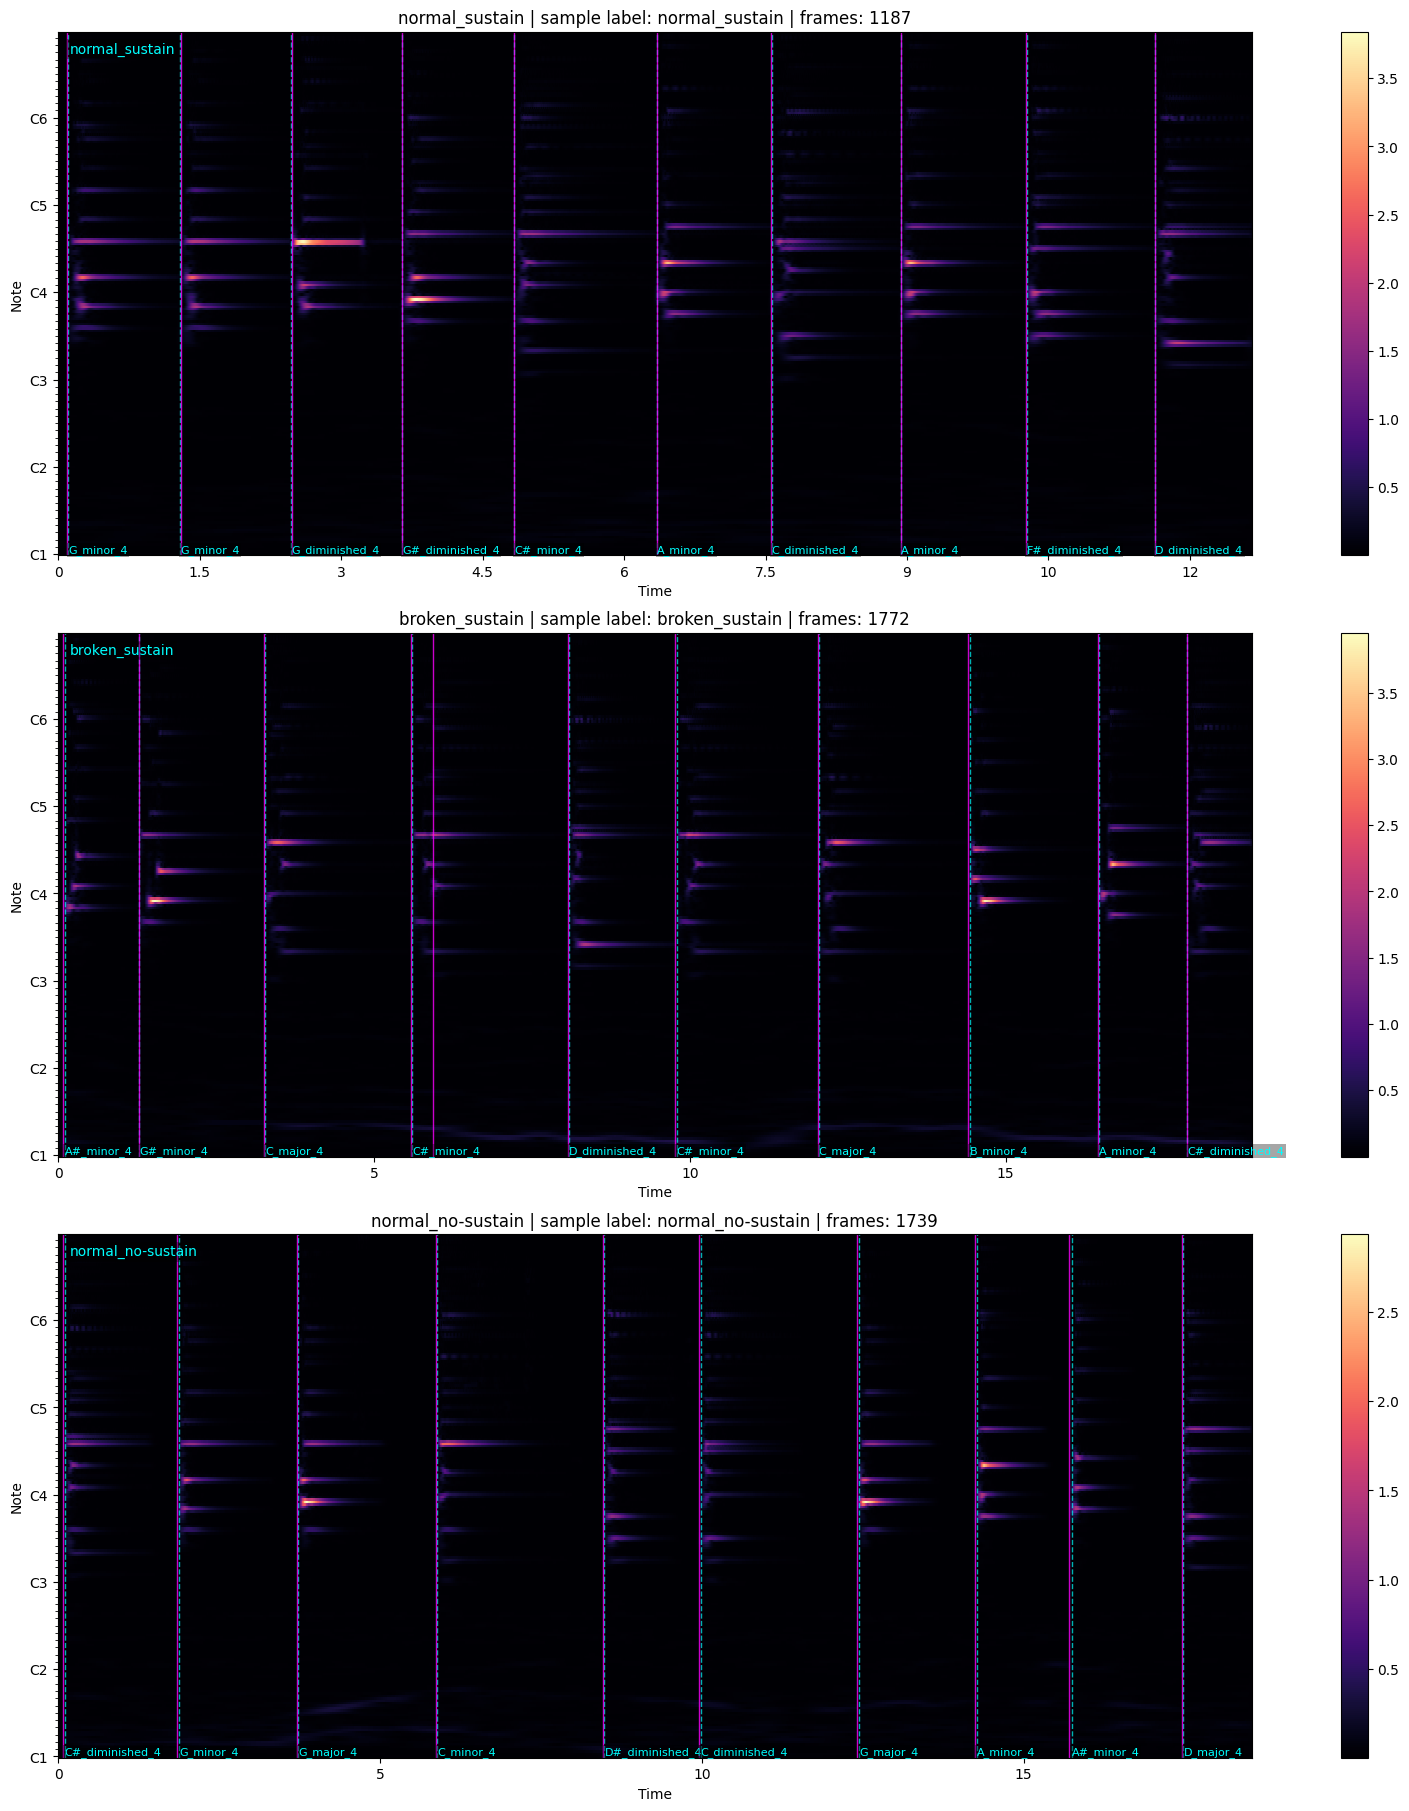

In [27]:
bock_ol_detections = detect_onsets_for_all_datasets(validation_datasets, PEAK_PICKING_BOCK_ONLINE)

## Comparison

In [28]:
import numpy as np
import pandas as pd
import mir_eval.onset
from IPython.display import display

def evaluate_onset_bundle(detection_bundle, method_name):
    rows = []
    for dataset_name, dataset_result in detection_bundle.items():
        for sample_index, detection in enumerate(dataset_result["detections"]):
            reference_onsets = np.asarray([annotation["start"] for annotation in detection["annotation"]], dtype=float)
            estimated_onsets = np.asarray(detection["onset_times"], dtype=float)
            scores = mir_eval.onset.evaluate(np.sort(reference_onsets), np.sort(estimated_onsets))

            rows.append({
                "method": method_name,
                "dataset": dataset_name,
                "sample_index": sample_index,
                "num_reference_onsets": int(reference_onsets.size),
                "num_estimated_onsets": int(estimated_onsets.size),
                **scores,
            })

    return pd.DataFrame(rows)

mcfee_results_df = evaluate_onset_bundle(mcfee_detections, "(McFee et al.) Offline")
bock_results_df = evaluate_onset_bundle(bock_detections, "(Bock & Widmer) Offline")
bock_ol_results_df = evaluate_onset_bundle(bock_ol_detections, "(Bock & Widmer) Online")
all_results_df = pd.concat([mcfee_results_df, bock_results_df, bock_ol_results_df], ignore_index=True)

identifier_columns = ["method", "dataset", "sample_index"]
metric_columns = [column for column in all_results_df.columns if column not in identifier_columns + ["num_reference_onsets", "num_estimated_onsets"]]

sample_results_df = all_results_df.sort_values(["dataset", "sample_index", "method"])
display(sample_results_df)

# sample_comparison_df = mcfee_results_df.merge(
#     bock_results_df,
#     on=["dataset", "sample_index"],
#     suffixes=("_mcfee", "_bock", "_bock_ol"),
# )

# for column in metric_columns:
#     mcfee_column = f"{column}_mcfee"
#     bock_column = f"{column}_bock"
#     bock_ol_column = f"{column}_bock_ol"
#     if mcfee_column in sample_comparison_df.columns and bock_column in sample_comparison_df.columns:
#         sample_comparison_df[f"{column}_delta"] = sample_comparison_df[bock_column] - sample_comparison_df[mcfee_column]

summary_df = (
    all_results_df
    .groupby(["dataset", "method"], as_index=False)[metric_columns + ["num_reference_onsets", "num_estimated_onsets"]]
    .mean(numeric_only=True)
    .sort_values(["dataset", "method"])
)
display(summary_df)

# comparison_df = summary_df.pivot(index="dataset", columns="method")
# comparison_df.columns = [f"{metric} | {method}" for metric, method in comparison_df.columns]
# for column in metric_columns:
#     mcfee_column = f"{column} (McFee et al.)"
#     bock_column = f"{column} (Bock & Widmer)"
#     if mcfee_column in comparison_df.columns and bock_column in comparison_df.columns:
#         comparison_df[f"{column} | delta (bock - mcfee)"] = comparison_df[bock_column] - comparison_df[mcfee_column]

# display(comparison_df.reset_index())

overall_summary_df = (
    all_results_df
    .groupby("method", as_index=False)[metric_columns + ["num_reference_onsets", "num_estimated_onsets"]]
    .mean(numeric_only=True)
    .sort_values("method")
)
display(overall_summary_df)

,method,dataset,sample_index,num_reference_onsets,num_estimated_onsets,F-measure,Precision,Recall
72,(Bock & Widmer) Offline,broken_sustain,0,10,10,0.100000,0.100000,0.1
134,(Bock & Widmer) Online,broken_sustain,0,10,11,0.952381,0.909091,1.0
10,(McFee et al.) Offline,broken_sustain,0,10,11,0.952381,0.909091,1.0
73,(Bock & Widmer) Offline,broken_sustain,1,10,10,0.000000,0.000000,0.0
135,(Bock & Widmer) Online,broken_sustain,1,10,10,1.000000,1.000000,1.0
...,...,...,...,...,...,...,...,...
132,(Bock & Widmer) Online,normal_sustain,8,10,10,1.000000,1.000000,1.0
8,(McFee et al.) Offline,normal_sustain,8,10,10,1.000000,1.000000,1.0
71,(Bock & Widmer) Offline,normal_sustain,9,10,10,0.000000,0.000000,0.0
133,(Bock & Widmer) Online,normal_sustain,9,10,10,1.000000,1.000000,1.0


,dataset,method,F-measure,Precision,Recall,num_reference_onsets,num_estimated_onsets
0,broken_sustain,(Bock & Widmer) Offline,0.160000,0.160000,0.160000,10.0,10.00000
1,broken_sustain,(Bock & Widmer) Online,0.980714,0.972273,0.990000,10.0,10.20000
2,broken_sustain,(McFee et al.) Offline,0.982857,0.976364,0.990000,10.0,10.15000
3,normal_no-sustain,(Bock & Widmer) Offline,0.159375,0.159375,0.159375,10.0,10.00000
4,normal_no-sustain,(Bock & Widmer) Online,0.995536,0.994318,0.996875,10.0,10.03125
5,normal_no-sustain,(McFee et al.) Offline,1.000000,1.000000,1.000000,10.0,10.00000
6,normal_sustain,(Bock & Widmer) Offline,0.050000,0.050000,0.050000,10.0,10.00000
7,normal_sustain,(Bock & Widmer) Online,1.000000,1.000000,1.000000,10.0,10.00000
8,normal_sustain,(McFee et al.) Offline,1.000000,1.000000,1.000000,10.0,10.00000


,method,F-measure,Precision,Recall,num_reference_onsets,num_estimated_onsets
0,(Bock & Widmer) Offline,0.141935,0.141935,0.141935,10.0,10.000000
1,(Bock & Widmer) Online,0.991475,0.988123,0.995161,10.0,10.080645
2,(McFee et al.) Offline,0.994470,0.992375,0.996774,10.0,10.048387
